In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)


In [4]:
df = pd.read_csv("mental_health_social_media_dataset.csv")
df

,person_name,age,date,gender,platform,daily_screen_time_min,social_media_time_min,negative_interactions_count,positive_interactions_count,sleep_hours,physical_activity_min,anxiety_level,stress_level,mood_level,mental_state
0,Reyansh Ghosh,35,1/1/2024,Male,Instagram,320,160,1,2,7.4,28,2,7,6,Stressed
1,Neha Patel,24,1/12/2024,Female,Instagram,453,226,1,3,6.7,15,3,8,5,Stressed
2,Ananya Naidu,26,1/6/2024,Male,Snapchat,357,196,1,2,7.2,24,3,7,6,Stressed
3,Neha Das,66,1/17/2024,Female,Snapchat,190,105,0,1,8.0,41,2,6,6,Stressed
4,Reyansh Banerjee,31,1/28/2024,Male,Snapchat,383,211,1,2,7.1,22,3,7,6,Stressed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,Sai Menon,42,1/21/2025,Female,WhatsApp,254,64,0,1,7.7,35,1,5,7,At_Risk
4996,Neha Ansari,33,1/26/2025,Female,TikTok,330,214,1,2,7.4,27,3,7,6,Stressed
4997,Aarav Sharma,13,2/6/2025,Male,TikTok,403,262,2,2,7.0,20,4,9,4,Stressed
4998,Aadhya Patil,21,2/17/2025,Male,TikTok,476,309,2,3,6.6,12,4,9,4,Stressed


In [5]:
df.shape

(5000, 15)

In [6]:
df.head()

,person_name,age,date,gender,platform,daily_screen_time_min,social_media_time_min,negative_interactions_count,positive_interactions_count,sleep_hours,physical_activity_min,anxiety_level,stress_level,mood_level,mental_state
0,Reyansh Ghosh,35,1/1/2024,Male,Instagram,320,160,1,2,7.4,28,2,7,6,Stressed
1,Neha Patel,24,1/12/2024,Female,Instagram,453,226,1,3,6.7,15,3,8,5,Stressed
2,Ananya Naidu,26,1/6/2024,Male,Snapchat,357,196,1,2,7.2,24,3,7,6,Stressed
3,Neha Das,66,1/17/2024,Female,Snapchat,190,105,0,1,8.0,41,2,6,6,Stressed
4,Reyansh Banerjee,31,1/28/2024,Male,Snapchat,383,211,1,2,7.1,22,3,7,6,Stressed


#  INITIAL DATA EXPLORATION & CLEANING

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   person_name                  5000 non-null   object 
 1   age                          5000 non-null   int64  
 2   date                         5000 non-null   object 
 3   gender                       5000 non-null   object 
 4   platform                     5000 non-null   object 
 5   daily_screen_time_min        5000 non-null   int64  
 6   social_media_time_min        5000 non-null   int64  
 7   negative_interactions_count  5000 non-null   int64  
 8   positive_interactions_count  5000 non-null   int64  
 9   sleep_hours                  5000 non-null   float64
 10  physical_activity_min        5000 non-null   int64  
 11  anxiety_level                5000 non-null   int64  
 12  stress_level                 5000 non-null   int64  
 13  mood_level        

In [9]:
df.isnull().sum()

person_name                    0
age                            0
date                           0
gender                         0
platform                       0
daily_screen_time_min          0
social_media_time_min          0
negative_interactions_count    0
positive_interactions_count    0
sleep_hours                    0
physical_activity_min          0
anxiety_level                  0
stress_level                   0
mood_level                     0
mental_state                   0
dtype: int64

In [10]:
df.describe().round(2)

,age,daily_screen_time_min,social_media_time_min,negative_interactions_count,positive_interactions_count,sleep_hours,physical_activity_min,anxiety_level,stress_level,mood_level
count,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00
mean,29.95,373.06,175.33,0.86,1.84,7.13,22.69,2.51,7.11,5.63
std,12.28,106.00,71.21,0.56,0.94,0.53,10.60,0.79,1.06,0.76
min,13.00,140.00,35.00,0.00,0.00,6.40,8.00,1.00,5.00,4.00
25%,21.00,310.00,118.00,1.00,1.00,6.70,14.00,2.00,6.00,5.00
50%,27.00,388.00,170.00,1.00,2.00,7.10,21.00,3.00,7.00,6.00
75%,35.25,461.00,231.00,1.00,2.00,7.45,29.00,3.00,8.00,6.00
max,69.00,520.00,338.00,2.00,4.00,8.30,46.00,4.00,9.00,7.00


In [11]:
df['date'] = pd.to_datetime(df['date'])

In [12]:
categorical_cols = ['person_name', 'gender', 'platform', 'mental_state']
for col in categorical_cols:
    df[col] = df[col].astype('category')


df['year_month'] = df['date'].dt.to_period('M')
df['month'] = df['date'].dt.month_name()
df['year'] = df['date'].dt.year

# بعد التعديل
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   person_name                  5000 non-null   category      
 1   age                          5000 non-null   int64         
 2   date                         5000 non-null   datetime64[ns]
 3   gender                       5000 non-null   category      
 4   platform                     5000 non-null   category      
 5   daily_screen_time_min        5000 non-null   int64         
 6   social_media_time_min        5000 non-null   int64         
 7   negative_interactions_count  5000 non-null   int64         
 8   positive_interactions_count  5000 non-null   int64         
 9   sleep_hours                  5000 non-null   float64       
 10  physical_activity_min        5000 non-null   int64         
 11  anxiety_level                5000 non-null 

# UNIVARIATE ANALYSIS (Visualizing Single Variables)

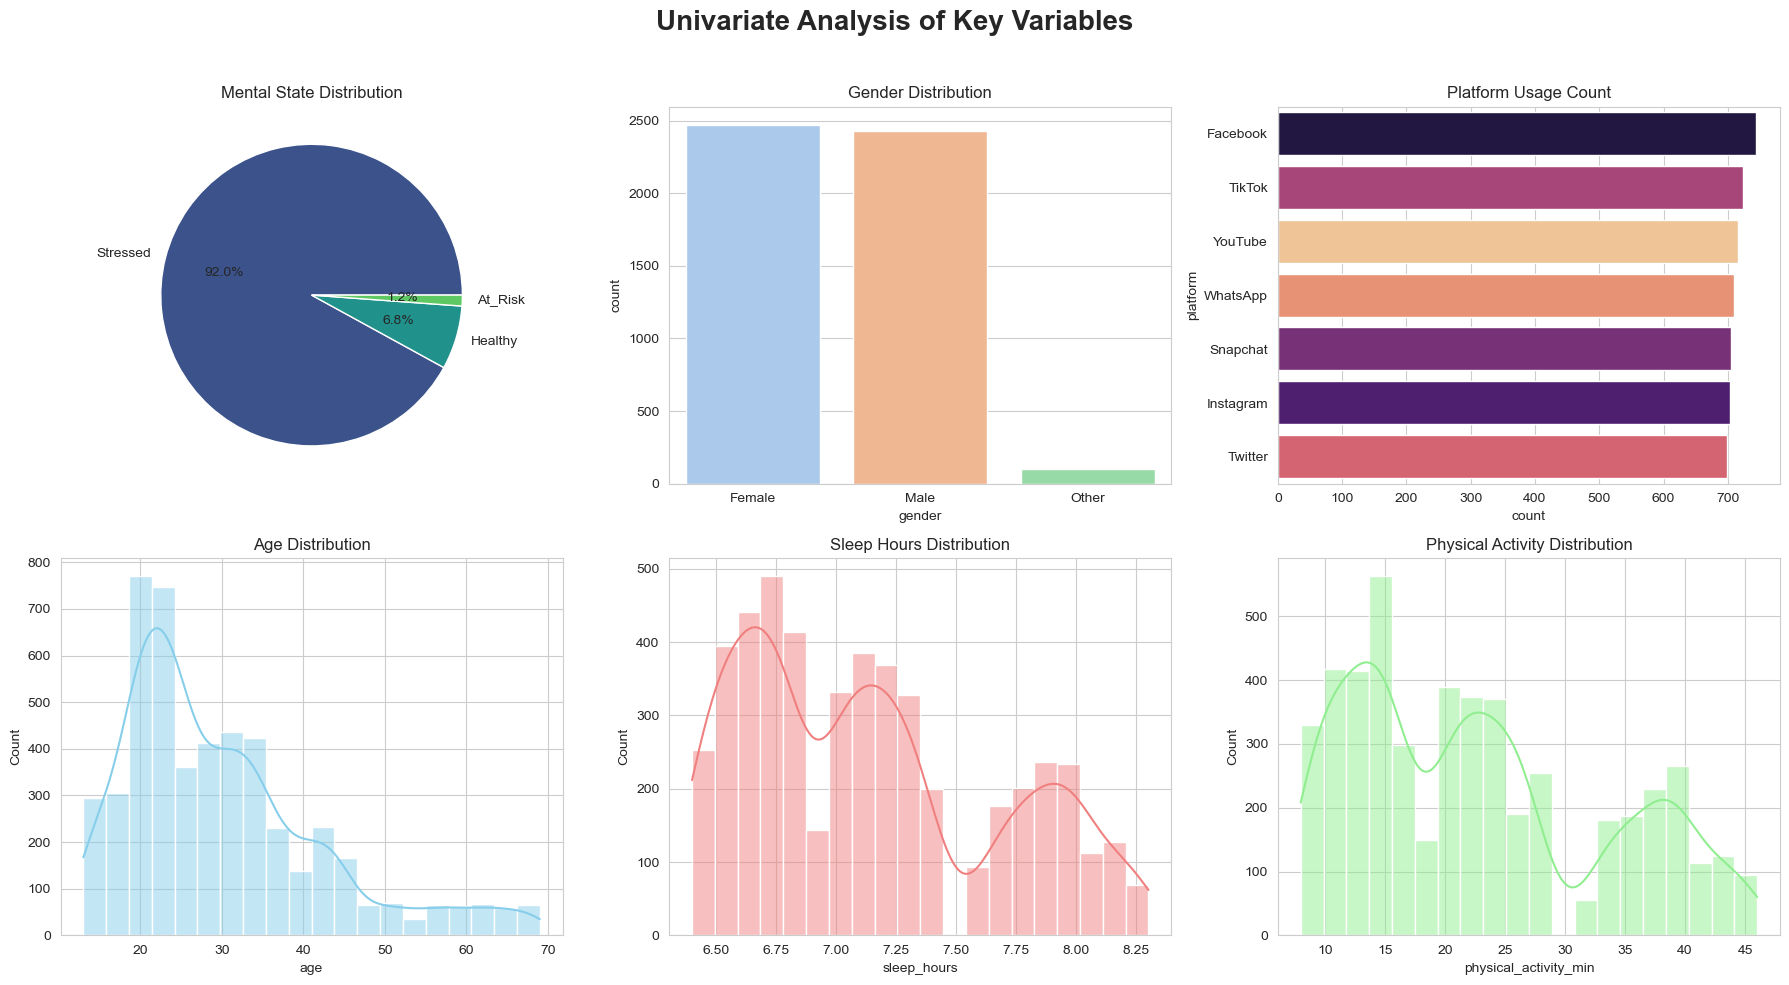

In [14]:
# # 5. UNIVARIATE ANALYSIS (Visualizing Single Variables)

#  2x3
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Univariate Analysis of Key Variables', fontsize=20, fontweight='bold')

# 1. Mental State Distribution
mental_state_counts = df['mental_state'].value_counts()
axes[0, 0].pie(mental_state_counts, labels=mental_state_counts.index, autopct='%1.1f%%', colors=sns.color_palette('viridis', 3))
axes[0, 0].set_title('Mental State Distribution')

# 2. Gender Distribution
sns.countplot(data=df, x='gender', ax=axes[0, 1], palette='pastel', hue='gender', legend=False)
axes[0, 1].set_title('Gender Distribution')

# 3. Platform Usage
sns.countplot(data=df, y='platform', ax=axes[0, 2], order=df['platform'].value_counts().index, palette='magma', hue='platform', legend=False)
axes[0, 2].set_title('Platform Usage Count')

# 4. Age Distribution
sns.histplot(df['age'], bins=20, kde=True, ax=axes[1, 0], color='skyblue')
axes[1, 0].set_title('Age Distribution')

# 5. Sleep Hours Distribution
sns.histplot(df['sleep_hours'], bins=20, kde=True, ax=axes[1, 1], color='lightcoral')
axes[1, 1].set_title('Sleep Hours Distribution')

# 6. Physical Activity Distribution
sns.histplot(df['physical_activity_min'], bins=20, kde=True, ax=axes[1, 2], color='lightgreen')
axes[1, 2].set_title('Physical Activity Distribution')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# ANALYSIS (Relationships between Variables)

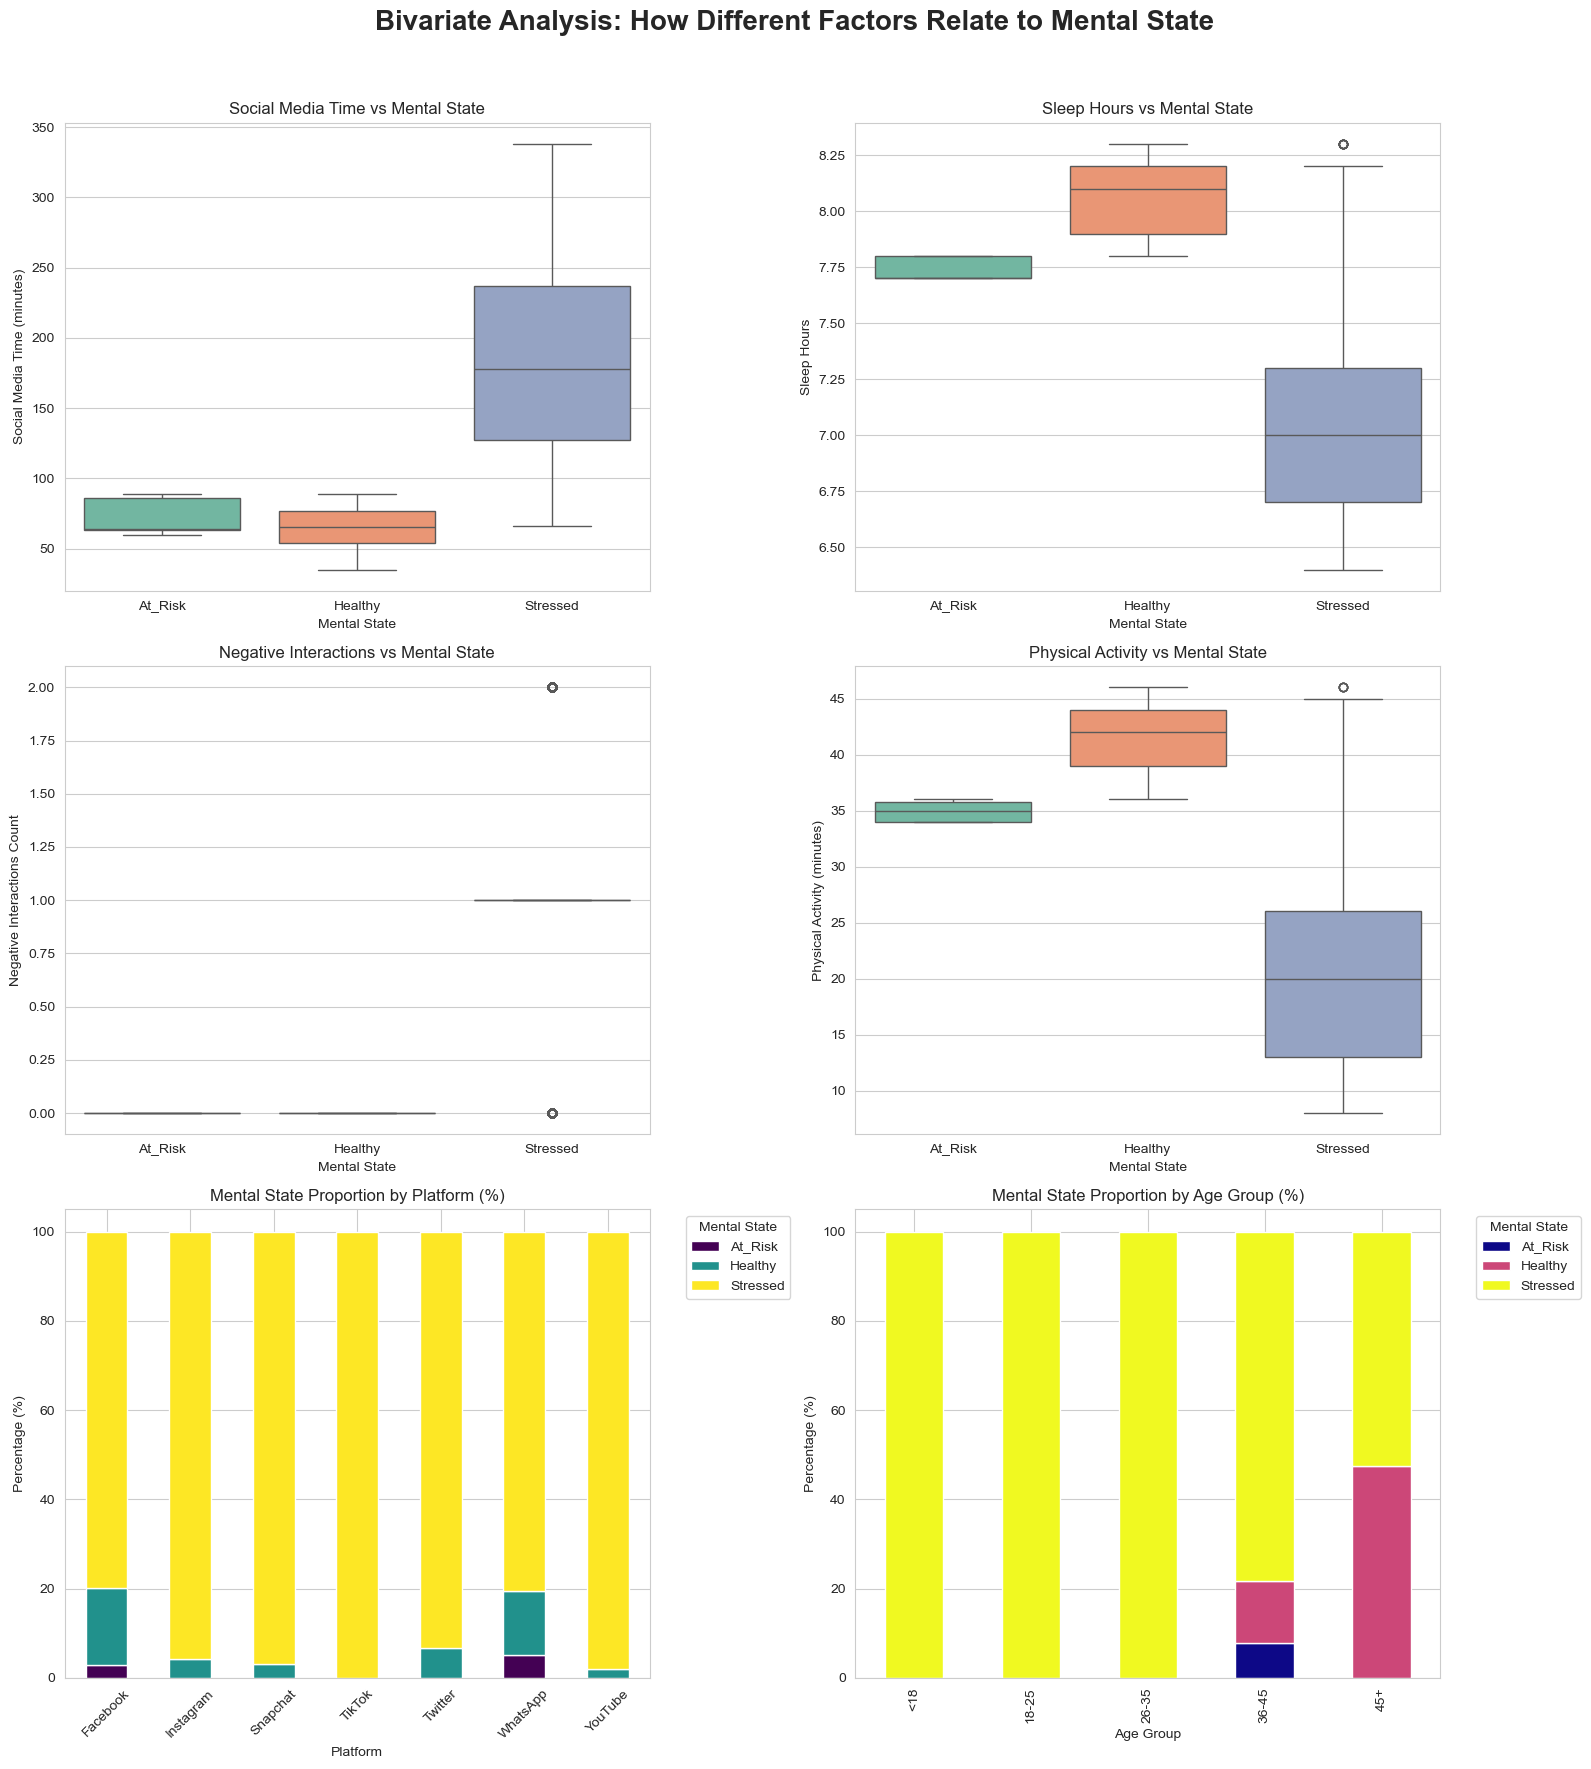

In [15]:
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle('Bivariate Analysis: How Different Factors Relate to Mental State', fontsize=20, fontweight='bold')

# 1. Social Media Time vs Mental State
sns.boxplot(data=df, x='mental_state', y='social_media_time_min', ax=axes[0, 0], palette='Set2', hue='mental_state', legend=False)
axes[0, 0].set_title('Social Media Time vs Mental State')
axes[0, 0].set_xlabel('Mental State')
axes[0, 0].set_ylabel('Social Media Time (minutes)')

# 2. Sleep Hours vs Mental State
sns.boxplot(data=df, x='mental_state', y='sleep_hours', ax=axes[0, 1], palette='Set2', hue='mental_state', legend=False)
axes[0, 1].set_title('Sleep Hours vs Mental State')
axes[0, 1].set_xlabel('Mental State')
axes[0, 1].set_ylabel('Sleep Hours')

# 3. Negative Interactions vs Mental State
sns.boxplot(data=df, x='mental_state', y='negative_interactions_count', ax=axes[1, 0], palette='Set2', hue='mental_state', legend=False)
axes[1, 0].set_title('Negative Interactions vs Mental State')
axes[1, 0].set_xlabel('Mental State')
axes[1, 0].set_ylabel('Negative Interactions Count')

# 4. Physical Activity vs Mental State
sns.boxplot(data=df, x='mental_state', y='physical_activity_min', ax=axes[1, 1], palette='Set2', hue='mental_state', legend=False)
axes[1, 1].set_title('Physical Activity vs Mental State')
axes[1, 1].set_xlabel('Mental State')
axes[1, 1].set_ylabel('Physical Activity (minutes)')

# 5. Platform vs Mental State (Stacked Bar Chart)
platform_mental = pd.crosstab(df['platform'], df['mental_state'], normalize='index') * 100
platform_mental.plot(kind='bar', stacked=True, ax=axes[2, 0], colormap='viridis')
axes[2, 0].set_title('Mental State Proportion by Platform (%)')
axes[2, 0].set_xlabel('Platform')
axes[2, 0].set_ylabel('Percentage (%)')
axes[2, 0].legend(title='Mental State', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[2, 0].tick_params(axis='x', rotation=45)

# 6. Age Group vs Mental State
# إنشاء فئات عمرية
bins = [0, 18, 25, 35, 45, 100]
labels = ['<18', '18-25', '26-35', '36-45', '45+']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)
age_mental = pd.crosstab(df['age_group'], df['mental_state'], normalize='index') * 100
age_mental.plot(kind='bar', stacked=True, ax=axes[2, 1], colormap='plasma')
axes[2, 1].set_title('Mental State Proportion by Age Group (%)')
axes[2, 1].set_xlabel('Age Group')
axes[2, 1].set_ylabel('Percentage (%)')
axes[2, 1].legend(title='Mental State', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

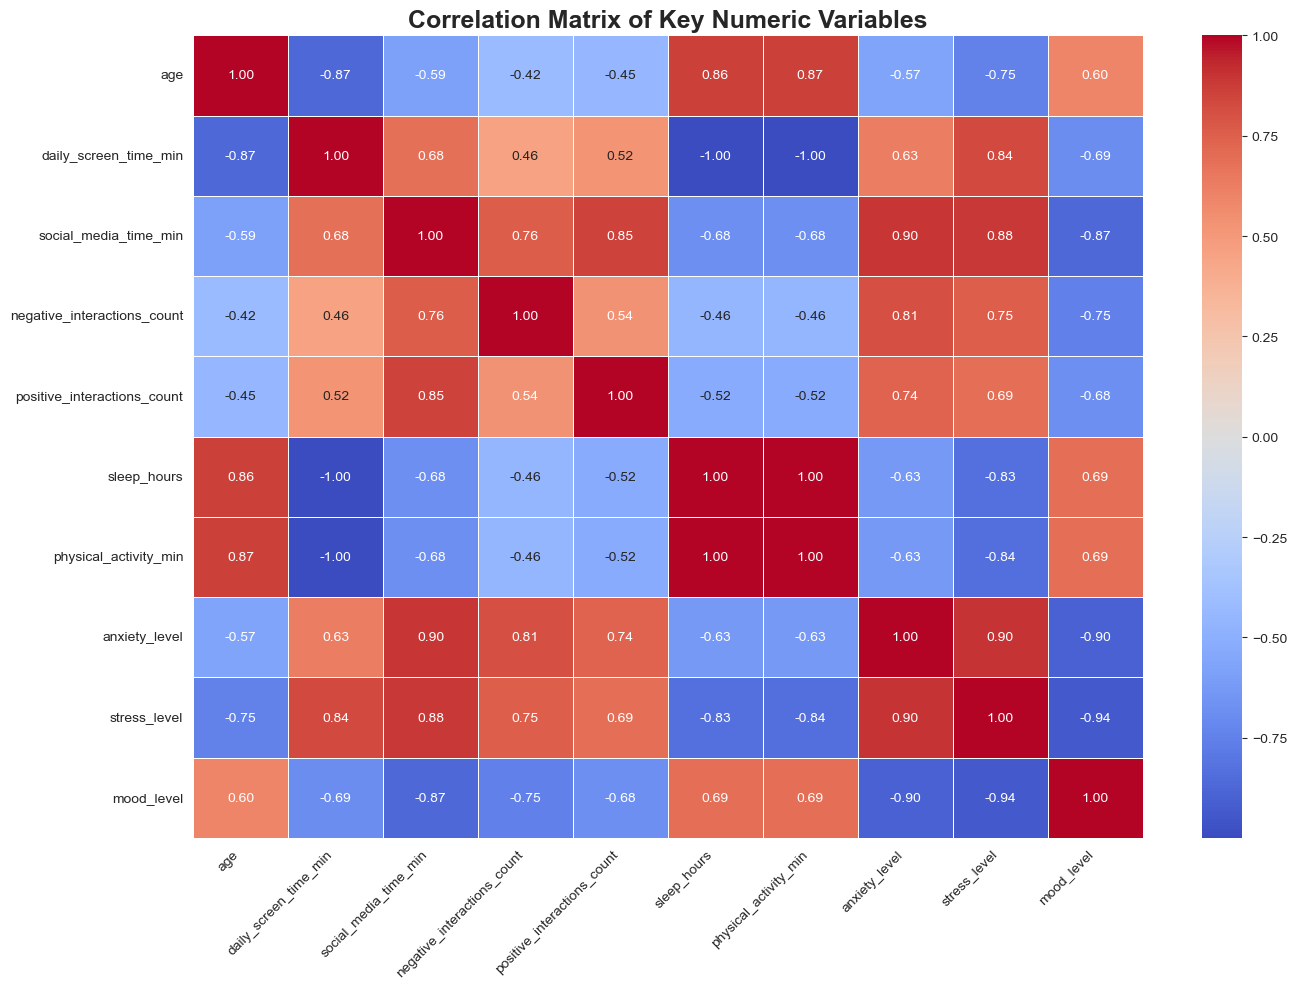

In [17]:
# # 7. CORRELATION HEATMAP (Numeric Variables)


numeric_cols = ['age', 'daily_screen_time_min', 'social_media_time_min', 
                'negative_interactions_count', 'positive_interactions_count', 
                'sleep_hours', 'physical_activity_min', 'anxiety_level', 
                'stress_level', 'mood_level']


corr_matrix = df[numeric_cols].corr()


plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Key Numeric Variables', fontsize=18, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

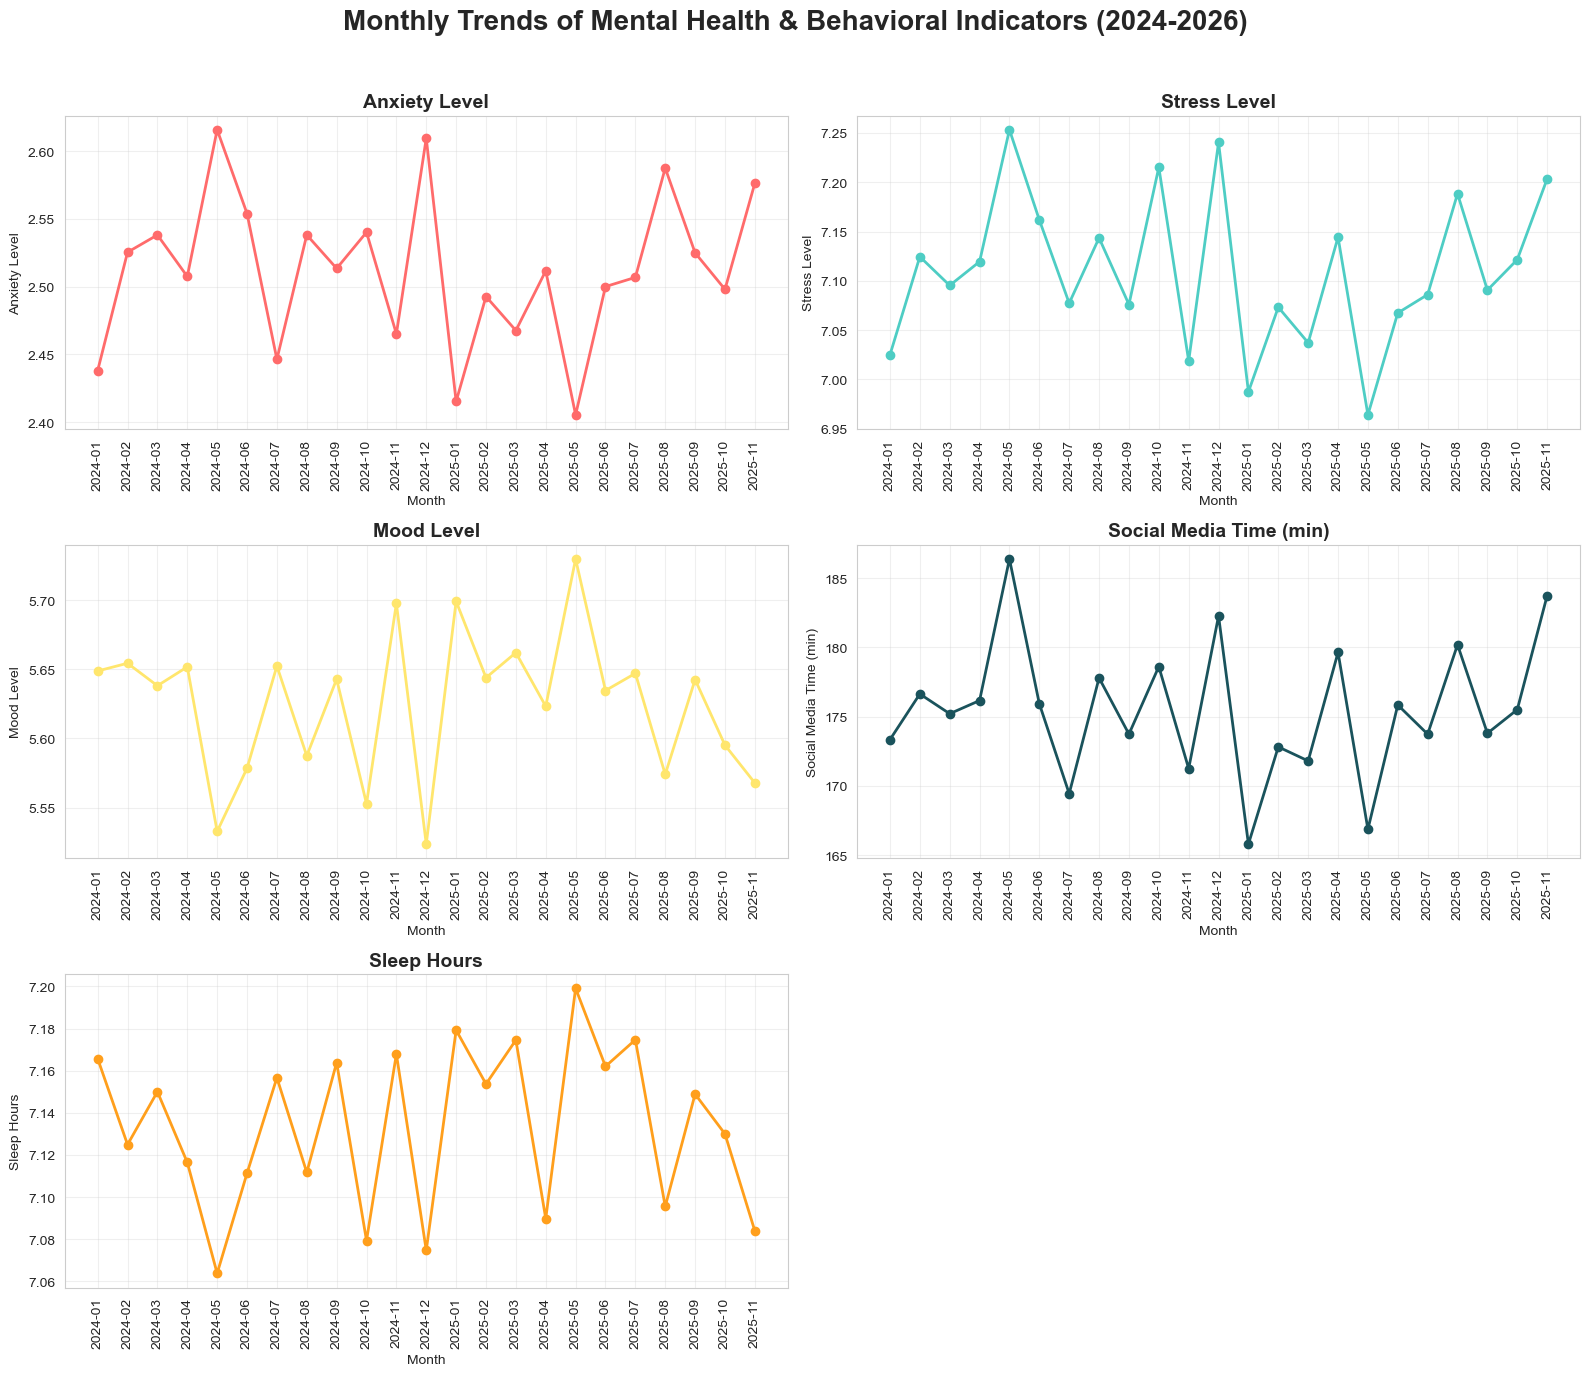

In [19]:
# # 8. TIME SERIES ANALYSIS (Trends Over Time)


monthly_trends = df.groupby('year_month').agg({
    'anxiety_level': 'mean',
    'stress_level': 'mean',
    'mood_level': 'mean',
    'social_media_time_min': 'mean',
    'sleep_hours': 'mean'
}).reset_index()

# 
monthly_trends['year_month'] = monthly_trends['year_month'].astype(str)

# رسم الاتجاهات الزمنية
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
fig.suptitle('Monthly Trends of Mental Health & Behavioral Indicators (2024-2026)', fontsize=20, fontweight='bold')


variables = ['anxiety_level', 'stress_level', 'mood_level', 'social_media_time_min', 'sleep_hours']
titles = ['Anxiety Level', 'Stress Level', 'Mood Level', 'Social Media Time (min)', 'Sleep Hours']
colors = ['#FF6B6B', '#4ECDC4', '#FFE66D', '#1A535C', '#FF9F1C']

for i, (var, title, color) in enumerate(zip(variables, titles, colors)):
    row, col = divmod(i, 2)
    axes[row, col].plot(monthly_trends['year_month'], monthly_trends[var], marker='o', linestyle='-', color=color, linewidth=2)
    axes[row, col].set_title(title, fontsize=14, fontweight='bold')
    axes[row, col].set_xlabel('Month')
    axes[row, col].set_ylabel(title)
    axes[row, col].tick_params(axis='x', rotation=90)
    axes[row, col].grid(True, alpha=0.3)

# اخفاء اخر رسمه الفاضيه
axes[2, 1].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

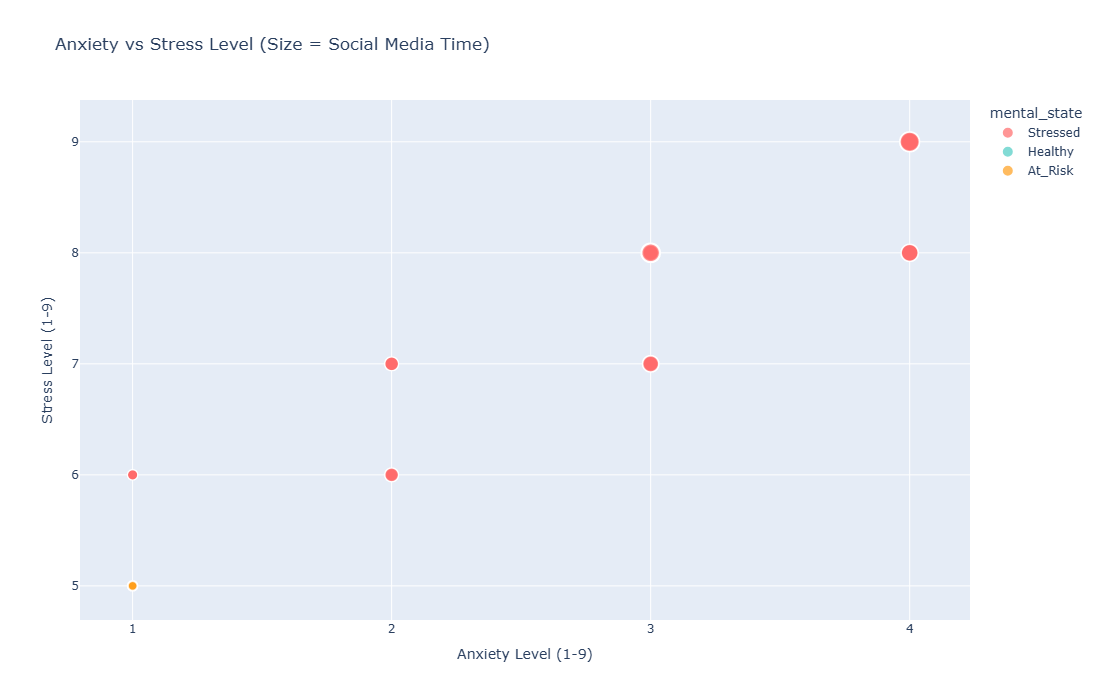

In [20]:
# # 9. INTERACTIVE SCATTER PLOT (Anxiety vs Stress, colored by Mental State)

fig = px.scatter(df, 
                 x='anxiety_level', 
                 y='stress_level', 
                 color='mental_state',
                 size='social_media_time_min',
                 hover_data=['age', 'platform', 'sleep_hours'],
                 title='Anxiety vs Stress Level (Size = Social Media Time)',
                 labels={'anxiety_level': 'Anxiety Level (1-9)', 
                         'stress_level': 'Stress Level (1-9)'},
                 color_discrete_map={'Stressed': '#FF6B6B', 
                                     'Healthy': '#4ECDC4', 
                                     'At_Risk': '#FF9F1C'},
                 width=1000,
                 height=700)

fig.update_layout(
    xaxis=dict(tickmode='linear', tick0=1, dtick=1),
    yaxis=dict(tickmode='linear', tick0=1, dtick=1)
)

fig.show()

In [ ]:
# # 10. KEY INSIGHTS SUMMARY

print("="*60)
print(" " * 15 + " KEY INSIGHTS SUMMARY ")
print("="*60)

# 1. Total records
print(f"1. Total Participants: {len(df):,}")

# 2. Mental State Distribution
stressed_pct = (df['mental_state'] == 'Stressed').mean() * 100
healthy_pct = (df['mental_state'] == 'Healthy').mean() * 100
at_risk_pct = (df['mental_state'] == 'At_Risk').mean() * 100
print(f"2. Mental State Distribution: Stressed ({stressed_pct:.1f}%), Healthy ({healthy_pct:.1f}%), At_Risk ({at_risk_pct:.1f}%)")

# 3. Platform with highest At_Risk percentage
platform_risk = df.groupby('platform')['mental_state'].apply(lambda x: (x == 'At_Risk').mean() * 100).sort_values(ascending=False)
print(f"3. Platform with Highest 'At_Risk' Percentage: {platform_risk.index[0]} ({platform_risk.values[0]:.1f}%)")

# 4. Correlation Insights
corr_anxiety_stress = df['anxiety_level'].corr(df['stress_level'])
corr_sleep_mood = df['sleep_hours'].corr(df['mood_level'])
corr_social_stress = df['social_media_time_min'].corr(df['stress_level'])
print(f"4. Key Correlations:")
print(f"   - Anxiety & Stress: {corr_anxiety_stress:.2f} (Strong Positive)")
print(f"   - Sleep Hours & Mood: {corr_sleep_mood:.2f} (Strong Positive)")
print(f"   - Social Media Time & Stress: {corr_social_stress:.2f} (Moderate Positive)")

# 5. Average values by Mental State
print("\n5. Average Metrics by Mental State:")
avg_by_state = df.groupby('mental_state')[['social_media_time_min', 'sleep_hours', 'anxiety_level', 'stress_level', 'mood_level']].mean().round(1)
print(avg_by_state)